In [1]:
# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import os
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np

# For plotting
%matplotlib inline
import matplotlib.pyplot as plt

# Sionna imports
from sionna.phy import Block
from sionna.phy.channel.tr38901 import Antenna, AntennaArray, CDL
from sionna.phy.channel import OFDMChannel
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import (ResourceGrid, ResourceGridMapper, LSChannelEstimator,
                             LMMSEEqualizer, ResourceGridDemapper)
from sionna.phy.utils import ebnodb2no, insert_dims, expand_to_rank, PlotBER
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.mapping import Mapper, Demapper, BinarySource
import time
# Set seed for reproducible random number generation
sionna.phy.config.seed = 42
device = sionna.phy.config.device

在本次實驗中將建立由神經網路構成的訊號接收器，從Channel estimation到Demodulation的步驟全部由AI來計算，並和基於LS estimation+Equalization以及Perfect CSI+Equalization的方法來進行比較(。

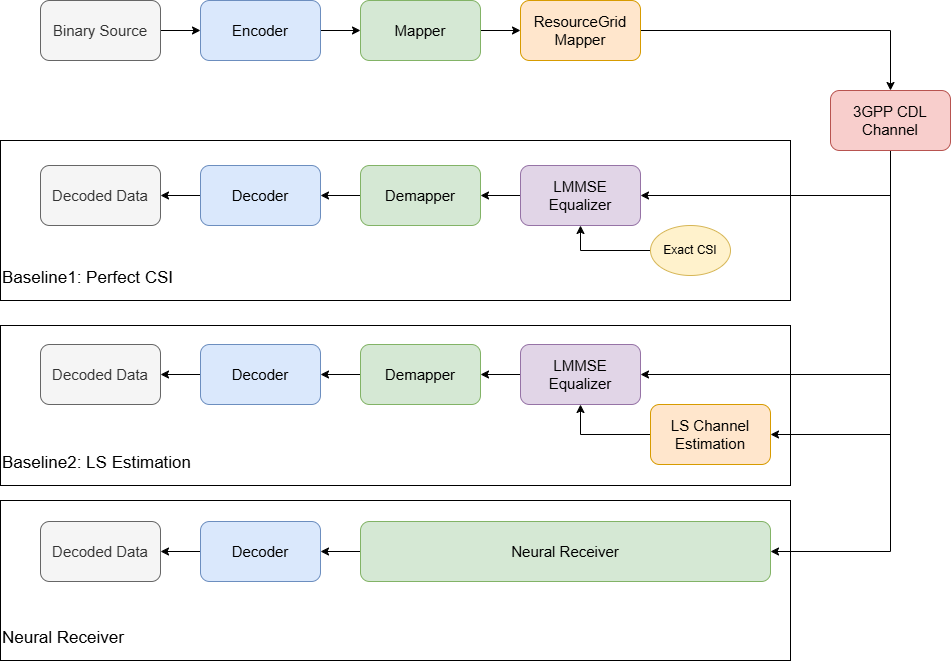

## Simulation Parameters

In [2]:
# Bit per channel use
NUM_BITS_PER_SYMBOL = 2  # QPSK

# Minimum value of Eb/N0 [dB] for simulations
EBN0_DB_MIN = -3.0

# Maximum value of Eb/N0 [dB] for simulations
EBN0_DB_MAX = 5.0

# How many examples are processed by Sionna in parallel
BATCH_SIZE = 128

# Coding rate
CODERATE = 0.5

# Define the number of UT and BS antennas
NUM_UT = 1
NUM_BS = 1
NUM_UT_ANT = 1
NUM_BS_ANT = 2

# The number of transmitted streams is equal to the number of UT antennas
# in both uplink and downlink
NUM_STREAMS_PER_TX = NUM_UT_ANT

# Create an RX-TX association matrix.
# RX_TX_ASSOCIATION[i,j]=1 means that receiver i gets at least one stream
# from transmitter j. Depending on the transmission direction (uplink or downlink),
# the role of UT and BS can change.
# For example, considering a system with 2 RX and 4 TX, the RX-TX
# association matrix could be
# [ [1 , 1, 0, 0],
#   [0 , 0, 1, 1] ]
# which indicates that the RX 0 receives from TX 0 and 1, and RX 1 receives from
# TX 2 and 3.
#
# In this notebook, as we have only a single transmitter and receiver,
# the RX-TX association matrix is simply:
RX_TX_ASSOCIATION = np.array([[1]])

# Instantiate a StreamManagement object
# This determines which data streams are determined for which receiver.
# In this simple setup, this is fairly easy. However, it can get more involved
# for simulations with many transmitters and receivers.
STREAM_MANAGEMENT = StreamManagement(RX_TX_ASSOCIATION, NUM_STREAMS_PER_TX)

# Resource grid configuration
NUM_OFDM_SYMBOLS = 14
FFT_SIZE = 76

RESOURCE_GRID = ResourceGrid(num_ofdm_symbols=NUM_OFDM_SYMBOLS,
                             fft_size=FFT_SIZE,
                             subcarrier_spacing=30e3,
                             num_tx=NUM_UT,
                             num_streams_per_tx=NUM_STREAMS_PER_TX,
                             cyclic_prefix_length=6,
                             pilot_pattern="kronecker",
                             pilot_ofdm_symbol_indices=[2, 11])

# Carrier frequency in Hz.
CARRIER_FREQUENCY = 2.6e9

# Antenna setting
UT_ARRAY = Antenna(polarization="single",
                   polarization_type="V",
                   antenna_pattern="38.901",
                   carrier_frequency=CARRIER_FREQUENCY)
BS_ARRAY = AntennaArray(num_rows=1,
                        num_cols=int(NUM_BS_ANT / 2),
                        polarization="dual",
                        polarization_type="cross",
                        antenna_pattern="38.901",
                        carrier_frequency=CARRIER_FREQUENCY)

# Nominal delay spread in [s]. Please see the CDL documentation
# about how to choose this value.
DELAY_SPREAD = 100e-9

# The `direction` determines if the UT or BS is transmitting.
# In the `uplink`, the UT is transmitting.
DIRECTION = "uplink"

# Suitable values are ["A", "B", "C", "D", "E"]
CDL_MODEL = "C"

# UT speed [m/s]. BSs are always assumed to be fixed.
# The direction of travel will chosen randomly within the x-y plane.
SPEED = 10.0

# Configure a channel impulse reponse (CIR) generator for the CDL model.
CDL_CHANNEL = CDL(CDL_MODEL,
                  DELAY_SPREAD,
                  CARRIER_FREQUENCY,
                  UT_ARRAY,
                  BS_ARRAY,
                  DIRECTION,
                  min_speed=SPEED)

# Number of coded bits and information bits
N = int(RESOURCE_GRID.num_data_symbols * NUM_BITS_PER_SYMBOL)  # Number of coded bits
K = int(N * CODERATE)  # Number of information bits

## Implemention of an Advanced Neural Receiver
We will implement a neural receiver that operates over the entire resource grid of received symbols.

The neural receiver computes LLRs on the coded bits from the received resource grid of frequency-domain baseband symbols. 

(Image is from https://nvlabs.github.io/sionna/phy/tutorials/notebooks/Sionna_tutorial_part4.html)

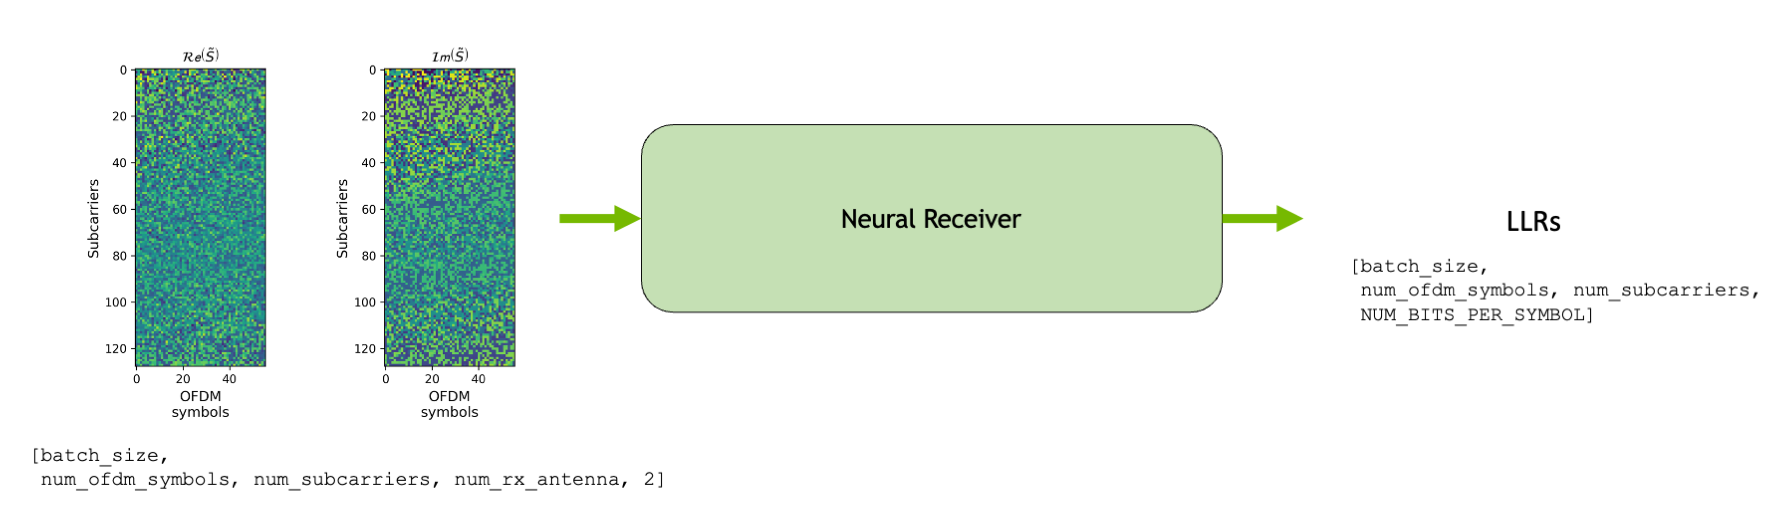

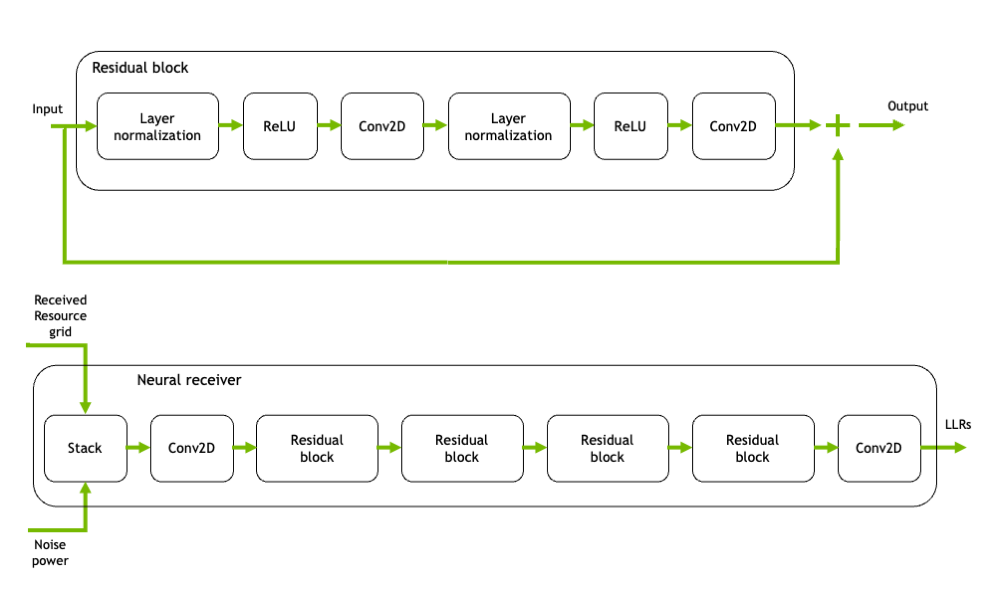

In [3]:
# CNN-based
class ResidualBlock(nn.Module):
    """
    Convolutional residual block with two convolutional layers, ReLU activation,
    layer normalization, and a skip connection.

    The number of convolutional channels of the input must match num_conv_channels
    for the skip connection to work.

    Input shape: [batch_size, num_conv_channels, num_ofdm_symbols, num_subcarriers]
    Output shape: [batch_size, num_conv_channels, num_ofdm_symbols, num_subcarriers]
    """

    def __init__(self, num_conv_channels: int = 128):
        super().__init__()
        # Layer normalization over the last three dimensions (C, H, W)
        self._layer_norm_1 = nn.LayerNorm([num_conv_channels, NUM_OFDM_SYMBOLS, FFT_SIZE])
        self._conv_1 = nn.Conv2d(
            in_channels=num_conv_channels,
            out_channels=num_conv_channels,
            kernel_size=3,
            padding=1,  # 'same' padding
        )
        self._layer_norm_2 = nn.LayerNorm([num_conv_channels, NUM_OFDM_SYMBOLS, FFT_SIZE])
        self._conv_2 = nn.Conv2d(
            in_channels=num_conv_channels,
            out_channels=num_conv_channels,
            kernel_size=3,
            padding=1,
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        z = self._layer_norm_1(inputs)
        z = F.relu(z)
        z = self._conv_1(z)
        z = self._layer_norm_2(z)
        z = F.relu(z)
        z = self._conv_2(z)
        # Skip connection
        z = z + inputs
        return z


class NeuralReceiver(nn.Module):
    """
    Residual convolutional neural receiver.

    This neural receiver is fed with the post-DFT received samples, forming a
    resource grid of size num_ofdm_symbols x fft_size, and computes LLRs on
    the transmitted coded bits.

    Input
    -----
    y : [batch_size, num_rx_antenna, num_ofdm_symbols, num_subcarriers], complex
        Received post-DFT samples.
    no : [batch_size], float
        Noise variance.

    Output
    ------
    llr : [batch_size, num_ofdm_symbols, num_subcarriers, num_bits_per_symbol], float
        LLRs on the transmitted bits.
    """

    def __init__(self, num_conv_channels: int = 128):
        super().__init__()
        self._num_bits_per_symbol = NUM_BITS_PER_SYMBOL

        # Input convolution: 2*num_rx_antenna + 1 input channels (real, imag, noise)
        num_input_channels = 2 * NUM_BS_ANT + 1
        self._input_conv = nn.Conv2d(
            in_channels=num_input_channels,
            out_channels=num_conv_channels,
            kernel_size=3,
            padding=1,
        )
        # Residual blocks
        self._res_block_1 = ResidualBlock(num_conv_channels)
        self._res_block_2 = ResidualBlock(num_conv_channels)
        self._res_block_3 = ResidualBlock(num_conv_channels)
        self._res_block_4 = ResidualBlock(num_conv_channels)
        # Output convolution
        self._output_conv = nn.Conv2d(
            in_channels=num_conv_channels,
            out_channels=NUM_BITS_PER_SYMBOL,
            kernel_size=3,
            padding=1,
        )

    def forward(self, y: torch.Tensor, no: torch.Tensor) -> torch.Tensor:
        # y: [batch, num_rx_ant, num_ofdm_symbols, num_subcarriers]
        # no: [batch]

        # Feeding the noise power in log10 scale helps with the performance
        no = torch.log10(no)

        # Stack real and imaginary components
        y_real = y.real  # [batch, num_rx_ant, time, freq]
        y_imag = y.imag  # [batch, num_rx_ant, time, freq]

        # Reshape noise to [batch, 1, 1, 1] and broadcast
        batch_size = y.shape[0]
        no = no.view(-1, 1, 1, 1)
        no = no.expand(batch_size, 1, y.shape[2], y.shape[3])  # [batch, 1, time, freq]

        # Concatenate: [batch, 2*num_rx_ant + 1, time, freq]
        # PyTorch Conv2d expects channels-first format
        z = torch.cat([y_real, y_imag, no], dim=1)

        # Input conv
        z = self._input_conv(z)
        # Residual blocks
        z = self._res_block_1(z)
        z = self._res_block_2(z)
        z = self._res_block_3(z)
        z = self._res_block_4(z)
        # Output conv: [batch, num_bits_per_symbol, time, freq]
        z = self._output_conv(z)

        # Transpose to [batch, time, freq, num_bits_per_symbol]
        z = z.permute(0, 2, 3, 1)

        return z

## Define the OFDM System with Neural Receiver

In [4]:
class OFDMSystemNeuralReceiver(Block):  # Inherits from Sionna Block
    """
    End-to-end OFDM system with neural receiver.

    Inherits from Sionna Block for lazy building and device/precision management.
    """

    def __init__(self, training: bool):
        super().__init__()  # Must call the parent class initializer

        self._training = training
        self._k = K
        self._n = N

        # Transmitter components
        self._binary_source = BinarySource()
        if not training:
            self._encoder = LDPC5GEncoder(K, N)
        self._mapper = Mapper("qam", NUM_BITS_PER_SYMBOL)
        self._rg_mapper = ResourceGridMapper(RESOURCE_GRID)

        # Channel
        self._channel = OFDMChannel(CDL_CHANNEL, RESOURCE_GRID, add_awgn=True,
                                    normalize_channel=True, return_channel=False)

        # Neural receiver
        self._neural_receiver = NeuralReceiver().to(device)
        self._rg_demapper = ResourceGridDemapper(RESOURCE_GRID, STREAM_MANAGEMENT)

        # Decoder (only for evaluation)
        if not training:
            self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

    def call(self, batch_size: int, ebno_db: torch.Tensor):
        """
        Forward pass through the end-to-end system.

        Parameters
        ----------
        batch_size : int
            Number of samples in the batch
        ebno_db : torch.Tensor
            Eb/N0 in dB, shape [batch_size] or scalar

        Returns
        -------
        If training: loss (scalar)
        If not training: (bits, bits_hat) tuple
        """
        no = ebnodb2no(ebno_db, num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
                       coderate=CODERATE, resource_grid=RESOURCE_GRID)

        # Ensure no has shape [batch_size]
        if no.dim() == 0:
            no = no.expand(batch_size)

        # Transmitter
        if self._training:
            codewords = self._binary_source([batch_size, NUM_UT, NUM_UT_ANT, self._n])
        else:
            bits = self._binary_source([batch_size, NUM_UT, NUM_UT_ANT, self._k])
            codewords = self._encoder(bits)

        x = self._mapper(codewords)
        x_rg = self._rg_mapper(x)

        # Channel
        no_ = expand_to_rank(no, x_rg.ndim)
        y = self._channel(x_rg, no_)

        # Receiver
        y = y.squeeze(1)  # Remove num_rx dimension (assuming single receiver)
        llr = self._neural_receiver(y, no)
        llr = insert_dims(llr, 2, 1)  # Add dimensions for rg_demapper
        llr = self._rg_demapper(llr)
        llr = llr.reshape(batch_size, NUM_UT, NUM_UT_ANT, self._n)

        if self._training:
            # Compute BCE loss
            loss = F.binary_cross_entropy_with_logits(llr, codewords.float())
            return loss
        else:
            bits_hat = self._decoder(llr)
            return bits, bits_hat

## Training the Neural Receiver

In [5]:
train = True  # Change to True to train your own model
if train:
    # Number of iterations used for training
    NUM_TRAINING_ITERATIONS = 5000

    # Instantiating the end-to-end model for training
    model = OFDMSystemNeuralReceiver(training=True)

    # Use torch.compile for faster execution
    try:
        compiled_model = torch.compile(model, mode="reduce-overhead")
    except Exception:
        print("torch.compile not available, using eager mode")
        compiled_model = model

    # Adam optimizer (SGD variant)
    optimizer = torch.optim.Adam(model.parameters())

    # Training loop
    for i in range(NUM_TRAINING_ITERATIONS):
        # Sample a batch of SNRs
        ebno_db = torch.empty(BATCH_SIZE, device=device).uniform_(EBN0_DB_MIN, EBN0_DB_MAX)

        # Forward pass
        loss = compiled_model(BATCH_SIZE, ebno_db)

        # Computing and applying gradients
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print progress
        if i % 10 == 0:
            print(f"{i}/{NUM_TRAINING_ITERATIONS}  Loss: {loss.item():.2E}", end="\r")

    # Save the weights in a file
    torch.save(model._neural_receiver.state_dict(), 'weights-ofdm-neuralrx.pt')

4990/5000  Loss: 2.22E-01

## Benchmarking the Neural Receiver

In [6]:
class OFDMSystem(Block):  # Inherits from Sionna Block
    """
    End-to-end OFDM system with conventional receiver (LS estimation + LMMSE equalization).

    Inherits from Sionna Block for lazy building and device/precision management.
    """

    def __init__(self, perfect_csi: bool):
        super().__init__()  # Must call the parent class initializer

        self._perfect_csi = perfect_csi
        self._k = K

        # Transmitter components
        self._binary_source = BinarySource()
        self._encoder = LDPC5GEncoder(K, N)
        self._mapper = Mapper("qam", NUM_BITS_PER_SYMBOL)
        self._rg_mapper = ResourceGridMapper(RESOURCE_GRID)

        # Channel (return_channel=True to get channel frequency response)
        self._channel = OFDMChannel(CDL_CHANNEL, RESOURCE_GRID, add_awgn=True,
                                    normalize_channel=True, return_channel=True)

        # Receiver components
        self._ls_est = LSChannelEstimator(RESOURCE_GRID, interpolation_type="nn")
        self._lmmse_equ = LMMSEEqualizer(RESOURCE_GRID, STREAM_MANAGEMENT)
        self._demapper = Demapper("app", "qam", NUM_BITS_PER_SYMBOL)
        self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

    def call(self, batch_size: int, ebno_db: torch.Tensor):
        """
        Forward pass through the end-to-end system.

        Parameters
        ----------
        batch_size : int
            Number of samples in the batch
        ebno_db : torch.Tensor
            Eb/N0 in dB, shape [batch_size] or scalar

        Returns
        -------
        (bits, bits_hat) tuple
        """
        no = ebnodb2no(ebno_db, num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
                       coderate=CODERATE, resource_grid=RESOURCE_GRID)

        # Transmitter
        bits = self._binary_source([batch_size, NUM_UT, RESOURCE_GRID.num_streams_per_tx, self._k])
        codewords = self._encoder(bits)
        x = self._mapper(codewords)
        x_rg = self._rg_mapper(x)

        # Channel
        no_ = expand_to_rank(no, x_rg.ndim)
        y, h_freq = self._channel(x_rg, no_)

        # Receiver
        if self._perfect_csi:
            h_hat, err_var = h_freq, 0.0
        else:
            h_hat, err_var = self._ls_est(y, no)

        x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no)
        no_eff_ = expand_to_rank(no_eff, x_hat.ndim)
        llr = self._demapper(x_hat, no_eff_)
        bits_hat = self._decoder(llr)

        return bits, bits_hat

In [7]:
ber_plots = PlotBER("Advanced neural receiver")

baseline_ls = OFDMSystem(False)
ber_plots.simulate(baseline_ls,
                   ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
                   batch_size=BATCH_SIZE,
                   num_target_block_errors=100,  # simulate until 100 block errors occurred
                   legend="Baseline: LS Estimation",
                   soft_estimates=True,
                   max_mc_iter=100,  # run 100 Monte-Carlo simulations (each with batch_size samples)
                   show_fig=False)

baseline_pcsi = OFDMSystem(True)
ber_plots.simulate(baseline_pcsi,
                   ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
                   batch_size=BATCH_SIZE,
                   num_target_block_errors=100,  # simulate until 100 block errors occurred
                   legend="Baseline: Perfect CSI",
                   soft_estimates=True,
                   max_mc_iter=100,  # run 100 Monte-Carlo simulations (each with batch_size samples)
                   show_fig=False)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -3.0 | 3.6888e-01 | 1.0000e+00 |       43061 |      116736 |          128 |         128 |         0.1 |reached target block errors
   -2.579 | 3.5925e-01 | 1.0000e+00 |       41937 |      116736 |          128 |         128 |         0.0 |reached target block errors
   -2.158 | 3.4531e-01 | 1.0000e+00 |       40310 |      116736 |          128 |         128 |         0.0 |reached target block errors
   -1.737 | 3.3488e-01 | 1.0000e+00 |       39092 |      116736 |          128 |         128 |         0.0 |reached target block errors
   -1.316 | 3.2323e-01 | 1.0000e+00 |       37732 |      116736 |          128 |         128 |         0.0 |reached target block errors
   -0.895 | 3.1094e-01 | 1.0000e+00 |       36298 |      116736 |

(tensor([2.1953e-01, 1.9616e-01, 1.7103e-01, 1.3478e-01, 6.6106e-02, 1.4434e-02,
         6.9566e-04, 4.5744e-05, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00], device='cuda:0'),
 tensor([1.0000e+00, 1.0000e+00, 1.0000e+00, 9.9219e-01, 8.4375e-01, 3.3594e-01,
         3.3529e-02, 9.3750e-04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00], device='cuda:0'))

We then instantiate and evaluate the end-to-end system equipped with the neural receiver.

In [8]:
# Instantiating the end-to-end model for evaluation
model_neuralrx = OFDMSystemNeuralReceiver(training=False)

# Run one inference to build the model
model_neuralrx(1, torch.tensor(10.0))

# Load the trained weights
model_neuralrx._neural_receiver.load_state_dict(
    torch.load('weights-ofdm-neuralrx.pt', weights_only=True)
)

<All keys matched successfully>

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -3.0 | 2.3313e-01 | 1.0000e+00 |       27215 |      116736 |          128 |         128 |         0.0 |reached target block errors
   -2.579 | 2.1071e-01 | 1.0000e+00 |       24598 |      116736 |          128 |         128 |         0.0 |reached target block errors
   -2.158 | 1.9254e-01 | 1.0000e+00 |       22476 |      116736 |          128 |         128 |         0.0 |reached target block errors
   -1.737 | 1.6547e-01 | 1.0000e+00 |       19316 |      116736 |          128 |         128 |         0.0 |reached target block errors
   -1.316 | 1.0483e-01 | 9.5312e-01 |       12238 |      116736 |          122 |         128 |         0.0 |reached target block errors
   -0.895 | 3.6643e-02 | 6.2500e-01 |        8555 |      233472 |

(tensor([2.3313e-01, 2.1071e-01, 1.9254e-01, 1.6547e-01, 1.0483e-01, 3.6643e-02,
         6.8645e-03, 2.1149e-03, 1.4685e-03, 1.0903e-03, 4.7543e-04, 2.4757e-04,
         2.0139e-04, 2.3232e-04, 1.2430e-04, 5.8508e-05, 9.1660e-05, 1.0048e-04,
         9.6457e-05, 6.9302e-05], device='cuda:0'),
 tensor([1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 9.5312e-01, 6.2500e-01,
         1.3411e-01, 2.2545e-02, 1.0794e-02, 6.7188e-03, 3.1250e-03, 1.7187e-03,
         1.2500e-03, 1.0938e-03, 7.8125e-04, 3.9063e-04, 4.6875e-04, 7.0313e-04,
         5.4688e-04, 4.6875e-04], device='cuda:0'))

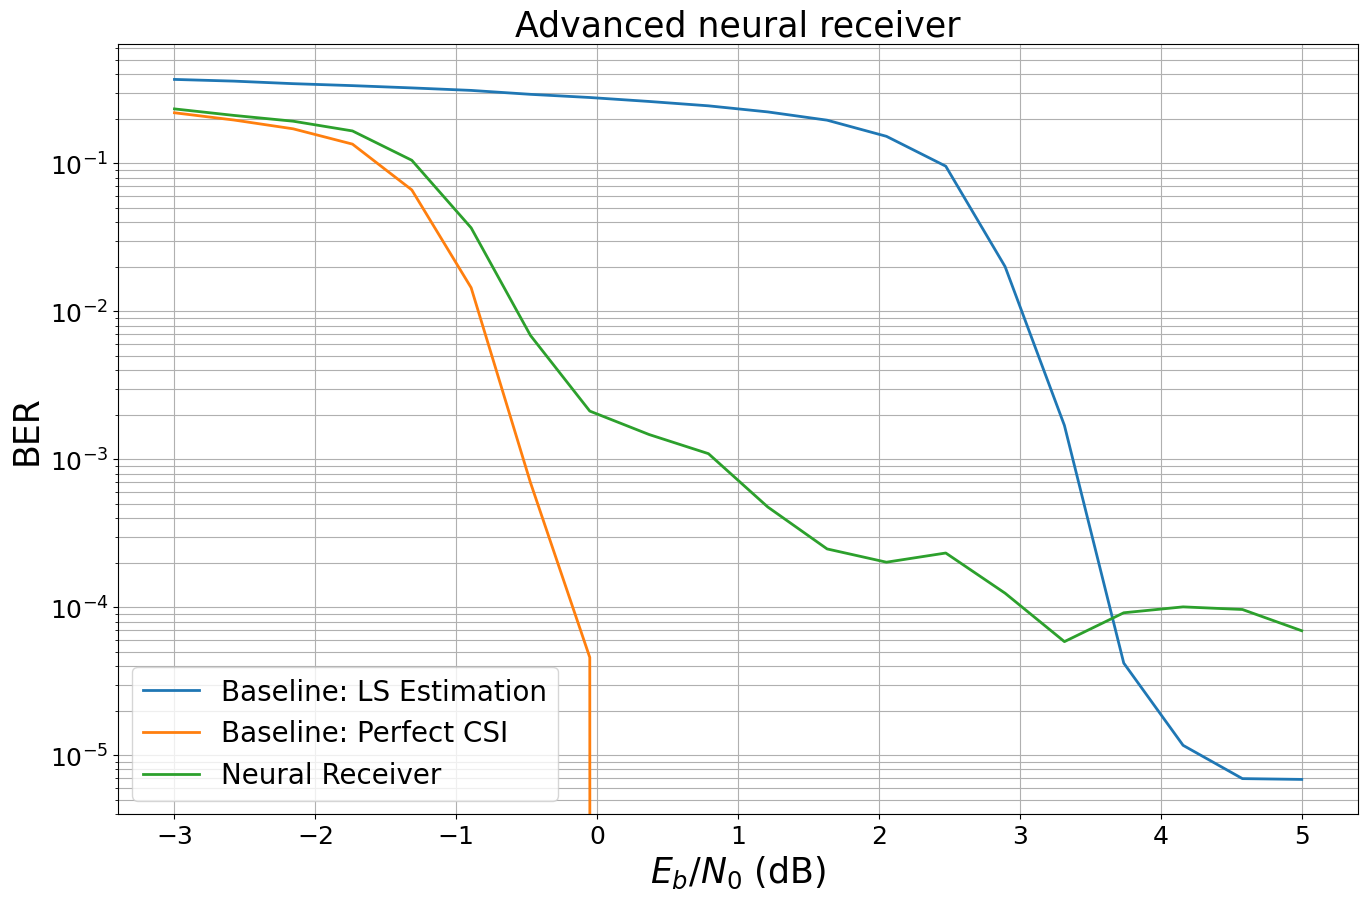

In [9]:
# Computing and plotting BER
ber_plots.simulate(model_neuralrx,
                   ebno_dbs=np.linspace(EBN0_DB_MIN, EBN0_DB_MAX, 20),
                   batch_size=BATCH_SIZE,
                   num_target_block_errors=100,
                   legend="Neural Receiver",
                   soft_estimates=True,
                   max_mc_iter=100,
                   show_fig=True)